In [2]:
from datasets import load_dataset


/Users/bhushanshah/Documents/All-About-LLMs/BERT/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
# Load 15% of the English Wikipedia dump
from datasets import load_dataset

ds = load_dataset("wikimedia/wikipedia", "20231101.en", split="train[:15%]")

In [12]:
ds.save_to_disk("../data/wikipedia_15percent")

Saving the dataset (7/7 shards): 100%|██████████| 961172/961172 [00:00<00:00, 979743.02 examples/s] 


In [7]:
print(ds)

Dataset({
    features: ['id', 'url', 'title', 'text'],
    num_rows: 64078
})


In [9]:
ds[0]['text'][:500]  # preview first 500 characters

'Anarchism is a political philosophy and movement that is skeptical of all justifications for authority and seeks to abolish the institutions it claims maintain unnecessary coercion and hierarchy, typically including nation-states, and capitalism. Anarchism advocates for the replacement of the state with stateless societies and voluntary free associations. As a historically left-wing movement, this reading of anarchism is placed on the farthest left of the political spectrum, usually described as'

In [2]:
import sys
sys.path.append("..")

In [3]:
from training.utils import load_checkpoint

In [6]:

from model.bert import BertForPretraining
import json
with open("../config/config_small_bert.json") as f:
    config = json.load(f)
model = BertForPretraining(config)
checkpoint = "/Users/bhushanshah/Documents/All-About-LLMs/BERT/new_checkpoints/bert_final.pt"
checkpoint = load_checkpoint(model, None, checkpoint, 'cpu')

In [7]:
checkpoint.keys()

dict_keys(['model_state_dict', 'optimizer_state_dict', 'step', 'training_losses'])

In [9]:
!pip install matplotlib

  Using cached matplotlib-3.10.6-cp313-cp313-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.0-cp313-cp313-macosx_10_13_universal2.whl.metadata (111 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pillow-11.3.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
Using cached matplotlib-3.10.6-cp313-cp313-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.60.0-cp313-cp313-macosx_10_13_universal2.whl (2.8 MB)
Using cached kiwisolver-1.4.9-cp313-cp313-macosx_11_0_arm64.whl (64 kB)
Using cached pillow-11.3.0-cp313-cp313-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing-3.2.5

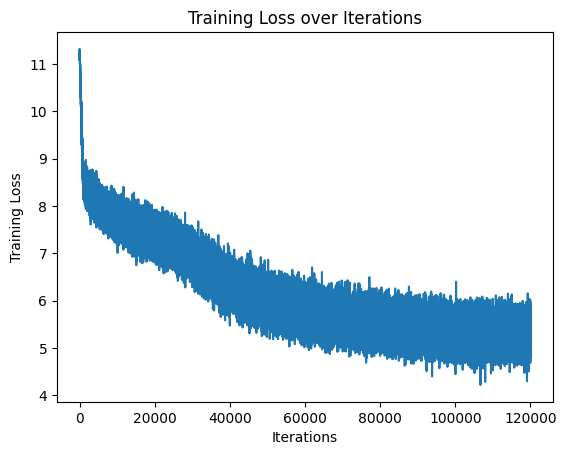

In [12]:
import matplotlib.pyplot as plt

plt.plot(checkpoint['training_losses'])
plt.xlabel('Iterations')
plt.ylabel('Training Loss')
plt.title('Training Loss over Iterations')
plt.savefig('../images/training_loss_plot.png')